Task 1: Student Score Prediction

Problem Statement: Build a machine learning model to predict students' exam scores based on academic and behavioral factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [5]:
for col in ['Parental_Education_Level', 'Distance_from_Home', 'Teacher_Quality']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

Exploratory Data Analysis (EDA)

In [7]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


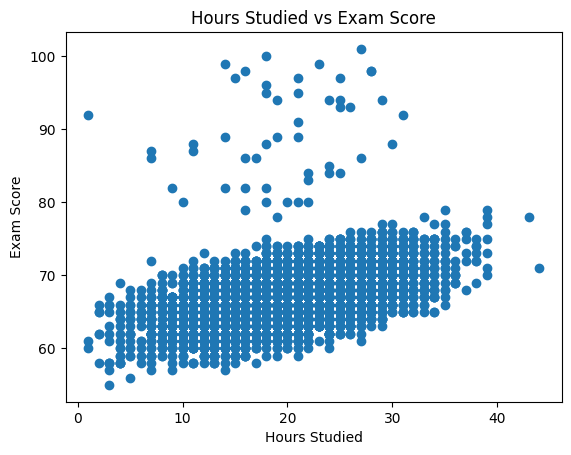

In [8]:
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

In [9]:
df.select_dtypes(include='object').columns

C:\Users\shahd\AppData\Local\Temp\ipykernel_22600\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')

In [36]:
# Reload fresh
df = pd.read_csv("StudentPerformanceFactors.csv")

# Fill missing values (mode) for known missing columns
for col in ["Parental_Education_Level", "Distance_from_Home", "Teacher_Quality"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# Strip spaces safely
text_cols = df.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    df[col] = df[col].str.strip()

In [37]:
ordinal_columns = [
    "Parental_Involvement",
    "Motivation_Level",
    "Teacher_Quality",
    "Family_Income",
    "Distance_from_Home",
    "Parental_Education_Level",
    "Access_to_Resources",
    "Peer_Influence"
]

for col in ordinal_columns:
    print(f"\nColumn: {col}")
    print(sorted(df_raw[col].dropna().unique()))


Column: Parental_Involvement
['High', 'Low', 'Medium']

Column: Motivation_Level
['High', 'Low', 'Medium']

Column: Teacher_Quality
['High', 'Low', 'Medium']

Column: Family_Income
['High', 'Low', 'Medium']

Column: Distance_from_Home
['Far', 'Moderate', 'Near']

Column: Parental_Education_Level
['College', 'High School', 'Postgraduate']

Column: Access_to_Resources
['High', 'Low', 'Medium']

Column: Peer_Influence
['Negative', 'Neutral', 'Positive']


In [38]:
# --- 1) ORDINAL mappings ---
level_map = {"Low": 1, "Medium": 2, "High": 3}
distance_map = {"Near": 1, "Moderate": 2, "Far": 3}
education_map = {"High School": 1, "College": 2, "Postgraduate": 3}
peer_map = {"Negative": 1, "Neutral": 2, "Positive": 3}

df["Parental_Involvement"] = df["Parental_Involvement"].map(level_map)
df["Motivation_Level"] = df["Motivation_Level"].map(level_map)
df["Teacher_Quality"] = df["Teacher_Quality"].map(level_map)
df["Family_Income"] = df["Family_Income"].map(level_map)
df["Access_to_Resources"] = df["Access_to_Resources"].map(level_map)
df["Distance_from_Home"] = df["Distance_from_Home"].map(distance_map)
df["Parental_Education_Level"] = df["Parental_Education_Level"].map(education_map)
df["Peer_Influence"] = df["Peer_Influence"].map(peer_map)

In [41]:
# --- 2) NOMINAL columns (one-hot encode) ---
nominal_cols = [
    "Extracurricular_Activities",
    "Internet_Access",
    "School_Type",
    "Learning_Disabilities",
    "Gender",
]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [42]:
# --- 3) Quick verification ---
print("Remaining missing values per column (should be 0):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nData types check (should be mostly int/float/bool):")
print(df.dtypes.value_counts())

Remaining missing values per column (should be 0):
Hours_Studied               0
Attendance                  0
Parental_Involvement        0
Access_to_Resources         0
Sleep_Hours                 0
Previous_Scores             0
Motivation_Level            0
Tutoring_Sessions           0
Family_Income               0
Teacher_Quality             0
Peer_Influence              0
Physical_Activity           0
Parental_Education_Level    0
Distance_from_Home          0
Exam_Score                  0
dtype: int64

Data types check (should be mostly int/float/bool):
int64    15
bool      5
Name: count, dtype: int64


In [43]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6607, 19)
y shape: (6607,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5285, 19)
Testing size: (1322, 19)


In [45]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.4442894562720815
RMSE: 1.7994293282174327
R2: 0.7709282415480215


In [49]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])
poly_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [50]:
y_pred_poly = poly_model.predict(X_test)

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial (degree=2) results")
print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R2:", r2_poly)

Polynomial (degree=2) results
MAE: 0.5598862049412244
RMSE: 1.8426892782220972
R2: 0.7597816507451821


In [53]:
comparison = {
    "Model": ["Linear", "Polynomial (deg=2)"],
    "MAE": [mae, mae_poly],
    "RMSE": [rmse, rmse_poly],
    "R2": [r2, r2_poly]
}

import pandas as pd
pd.DataFrame(comparison)

,Model,MAE,RMSE,R2
0,Linear,0.444289,1.799429,0.770928
1,Polynomial (deg=2),0.559886,1.842689,0.759782


In [54]:
X_no_sleep = X.drop("Sleep_Hours", axis=1)

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_sleep, y, test_size=0.2, random_state=42
)

model_ns = LinearRegression()
model_ns.fit(X_train_ns, y_train_ns)

y_pred_ns = model_ns.predict(X_test_ns)

r2_ns = r2_score(y_test_ns, y_pred_ns)

print("R2 without Sleep_Hours:", r2_ns)

R2 without Sleep_Hours: 0.771124742193771


In [55]:
important_features = [
    "Attendance",
    "Hours_Studied",
    "Previous_Scores",
    "Tutoring_Sessions"
]

X_small = df[important_features]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_small, y, test_size=0.2, random_state=42
)

model_s = LinearRegression()
model_s.fit(X_train_s, y_train_s)

y_pred_s = model_s.predict(X_test_s)

print("R2 with selected features:", r2_score(y_test_s, y_pred_s))

R2 with selected features: 0.6413573918421557


In [60]:
df2 = df.copy()

# Create new engineered feature
df2["Academic_Index"] = (
    df2["Hours_Studied"] +
    df2["Attendance"] +
    df2["Previous_Scores"]
) / 3

# Define features and target
X_new = df2.drop("Exam_Score", axis=1)
y_new = df2["Exam_Score"]

# Train-test split
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_new, y_new,
    test_size=0.2,
    random_state=42
)

# Train model
model_n = LinearRegression()
model_n.fit(X_train_n, y_train_n)

# Predict
y_pred_n = model_n.predict(X_test_n)

# Evaluate correctly
mae_n = mean_absolute_error(y_test_n, y_pred_n)
mse_n = mean_squared_error(y_test_n, y_pred_n)
rmse_n = np.sqrt(mse_n)
r2_n = r2_score(y_test_n, y_pred_n)

# Compare with baseline
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "With Academic_Index"],
    "MAE": [mae, mae_n],
    "RMSE": [rmse, rmse_n],
    "R2": [r2, r2_n]
})

comparison_df

,Model,MAE,RMSE,R2
0,Baseline,0.444289,1.799429,0.770928
1,With Academic_Index,0.444289,1.799429,0.770928


In [61]:
df3 = df.copy()

# New engineered feature (interaction)
df3["Study_Efficiency"] = df3["Hours_Studied"] * df3["Motivation_Level"]

# Define features and target
X_new3 = df3.drop("Exam_Score", axis=1)
y_new3 = df3["Exam_Score"]

# Train-test split
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_new3, y_new3,
    test_size=0.2,
    random_state=42
)

# Train model
model_3 = LinearRegression()
model_3.fit(X_train_3, y_train_3)

# Predict
y_pred_3 = model_3.predict(X_test_3)

# Evaluate
mae_3 = mean_absolute_error(y_test_3, y_pred_3)
mse_3 = mean_squared_error(y_test_3, y_pred_3)
rmse_3 = np.sqrt(mse_3)
r2_3 = r2_score(y_test_3, y_pred_3)

# Compare with baseline (uses your existing mae, rmse, r2 from baseline)
comparison_df3 = pd.DataFrame({
    "Model": ["Baseline", "With Study_Efficiency"],
    "MAE": [mae, mae_3],
    "RMSE": [rmse, rmse_3],
    "R2": [r2, r2_3]
})

comparison_df3

,Model,MAE,RMSE,R2
0,Baseline,0.444289,1.799429,0.770928
1,With Study_Efficiency,0.446246,1.799137,0.771003


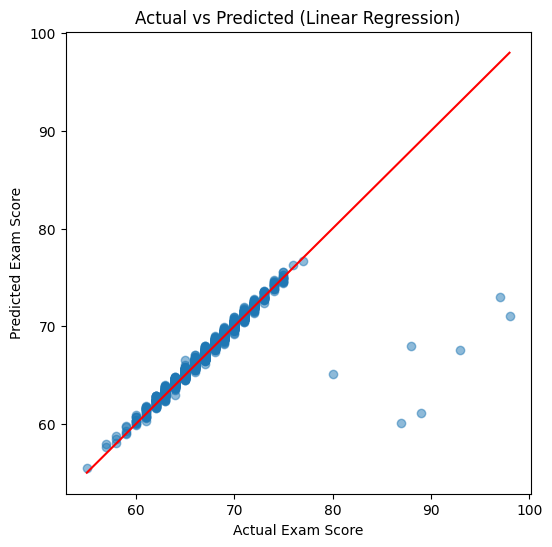

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

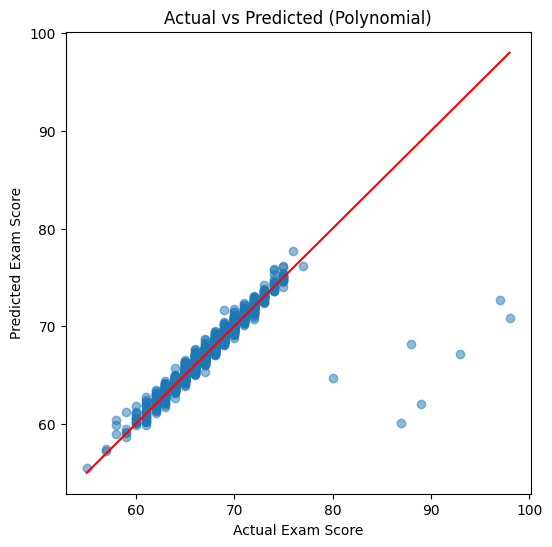

In [63]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_poly, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted (Polynomial)")
plt.show()

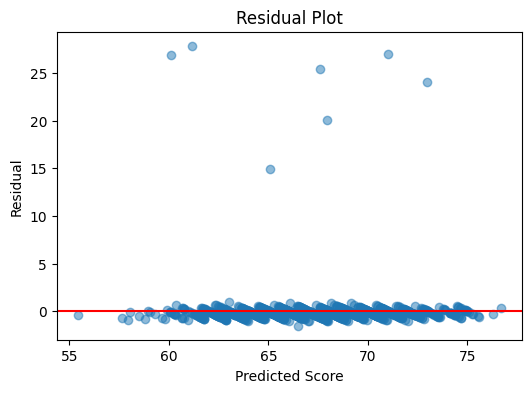

In [64]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Predicted Score")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

Final Conclusion: The linear regression model shows predictions closely aligned with the actual scores, indicating a strong linear relationship between features and the target variable.